In [3]:
import kagglehub
import os
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score, average_precision_score,
    precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from collections import Counter

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
csv_file_path = os.path.join(path, "creditcard.csv")

Path("results").mkdir(exist_ok=True)
Path("models").mkdir(exist_ok=True)

In [4]:
df = pd.read_csv(csv_file_path)

X = df.drop(['Class'], axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Original class distribution in training:")
print(f"  Normal: {(y_train==0).sum():,} ({(y_train==0).sum()/len(y_train)*100:.2f}%)")
print(f"  Fraud:  {(y_train==1).sum():,} ({(y_train==1).sum()/len(y_train)*100:.2f}%)")

Original class distribution in training:
  Normal: 227,451 (99.83%)
  Fraud:  394 (0.17%)


In [5]:
# APPLY CLASS WEIGHTING

print("\nTraining Logistic Regression with class_weight='balanced'...")
lr_balanced = LogisticRegression(
    max_iter=1000, 
    class_weight='balanced',  
    random_state=42,
    n_jobs=-1
)
lr_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = lr_balanced.predict(X_test_scaled)
y_proba_balanced = lr_balanced.predict_proba(X_test_scaled)[:, 1]

# Evaluate
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
tn, fp, fn, tp = cm_balanced.ravel()

metrics_balanced = {
    'accuracy': accuracy_score(y_test, y_pred_balanced),
    'precision': precision_score(y_test, y_pred_balanced, zero_division=0),
    'recall': recall_score(y_test, y_pred_balanced, zero_division=0),
    'f1': f1_score(y_test, y_pred_balanced, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba_balanced),
    'pr_auc': average_precision_score(y_test, y_proba_balanced)
}

print(f"\nClass-Weighted Model Performance:")
print(f"  Accuracy:  {metrics_balanced['accuracy']*100:.2f}%")
print(f"  Precision: {metrics_balanced['precision']*100:.2f}%")
print(f"  Recall:    {metrics_balanced['recall']*100:.2f}%")
print(f"  F1-Score:  {metrics_balanced['f1']*100:.2f}%")
print(f"  PR-AUC:    {metrics_balanced['pr_auc']:.4f}")


Training Logistic Regression with class_weight='balanced'...

Class-Weighted Model Performance:
  Accuracy:  97.55%
  Precision: 6.10%
  Recall:    91.84%
  F1-Score:  11.44%
  PR-AUC:    0.7190


In [6]:
# Random Undersampling

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)

print(f"   After undersampling:")
print(f"   Normal: {(y_train_rus==0).sum():,}")
print(f"   Fraud:  {(y_train_rus==1).sum():,}")
print(f"   Ratio: 1:1 (balanced)")

lr_rus = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_rus.fit(X_train_rus, y_train_rus)

y_pred_rus = lr_rus.predict(X_test_scaled)
y_proba_rus = lr_rus.predict_proba(X_test_scaled)[:, 1]

metrics_rus = {
    'accuracy': accuracy_score(y_test, y_pred_rus),
    'precision': precision_score(y_test, y_pred_rus, zero_division=0),
    'recall': recall_score(y_test, y_pred_rus, zero_division=0),
    'f1': f1_score(y_test, y_pred_rus, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba_rus),
    'pr_auc': average_precision_score(y_test, y_proba_rus)
}

print(f"   Performance: Recall={metrics_rus['recall']*100:.1f}%, Precision={metrics_rus['precision']*100:.1f}%")

# SMOTE (Synthetic Minority Over-sampling)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"   After SMOTE:")
print(f"   Normal: {(y_train_smote==0).sum():,}")
print(f"   Fraud:  {(y_train_smote==1).sum():,}")
print(f"   Ratio: 1:1 (balanced)")

lr_smote = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = lr_smote.predict(X_test_scaled)
y_proba_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]


metrics_smote = {
    'accuracy': accuracy_score(y_test, y_pred_smote),
    'precision': precision_score(y_test, y_pred_smote, zero_division=0),
    'recall': recall_score(y_test, y_pred_smote, zero_division=0),
    'f1': f1_score(y_test, y_pred_smote, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba_smote),
    'pr_auc': average_precision_score(y_test, y_proba_smote)
}

print(f"   Performance: Recall={metrics_smote['recall']*100:.1f}%, Precision={metrics_smote['precision']*100:.1f}%")

# SMOTE + Tomek Links

smote_tomek = SMOTETomek(random_state=42)
X_train_st, y_train_st = smote_tomek.fit_resample(X_train_scaled, y_train)

print(f"   After SMOTE + Tomek:")
print(f"   Normal: {(y_train_st==0).sum():,}")
print(f"   Fraud:  {(y_train_st==1).sum():,}")

lr_st = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_st.fit(X_train_st, y_train_st)

y_pred_st = lr_st.predict(X_test_scaled)
y_proba_st = lr_st.predict_proba(X_test_scaled)[:, 1]


metrics_st = {
    'accuracy': accuracy_score(y_test, y_pred_st),
    'precision': precision_score(y_test, y_pred_st, zero_division=0),
    'recall': recall_score(y_test, y_pred_st, zero_division=0),
    'f1': f1_score(y_test, y_pred_st, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba_st),
    'pr_auc': average_precision_score(y_test, y_proba_st)
}

print(f"   Performance: Recall={metrics_st['recall']*100:.1f}%, Precision={metrics_st['precision']*100:.1f}%")

   After undersampling:
   Normal: 394
   Fraud:  394
   Ratio: 1:1 (balanced)
   Performance: Recall=91.8%, Precision=3.8%
   After SMOTE:
   Normal: 227,451
   Fraud:  227,451
   Ratio: 1:1 (balanced)
   Performance: Recall=91.8%, Precision=5.8%
   After SMOTE + Tomek:
   Normal: 227,451
   Fraud:  227,451
   Performance: Recall=91.8%, Precision=5.8%


## Comparing All Techniques

We will now compare the different techniques using metrics such as accuracy, precision, recall, and f1-score



[STEP 3.3] Comparing All Techniques...

IMBALANCE HANDLING COMPARISON
           Technique Accuracy Precision Recall F1-Score PR-AUC
     Class Weighting   97.55%     6.10% 91.84%   11.44% 0.7190
Random Undersampling   96.02%     3.83% 91.84%    7.36% 0.6563
               SMOTE   97.41%     5.78% 91.84%   10.88% 0.7245
       SMOTE + Tomek   97.41%     5.78% 91.84%   10.88% 0.7245

Plotting comparison curves...


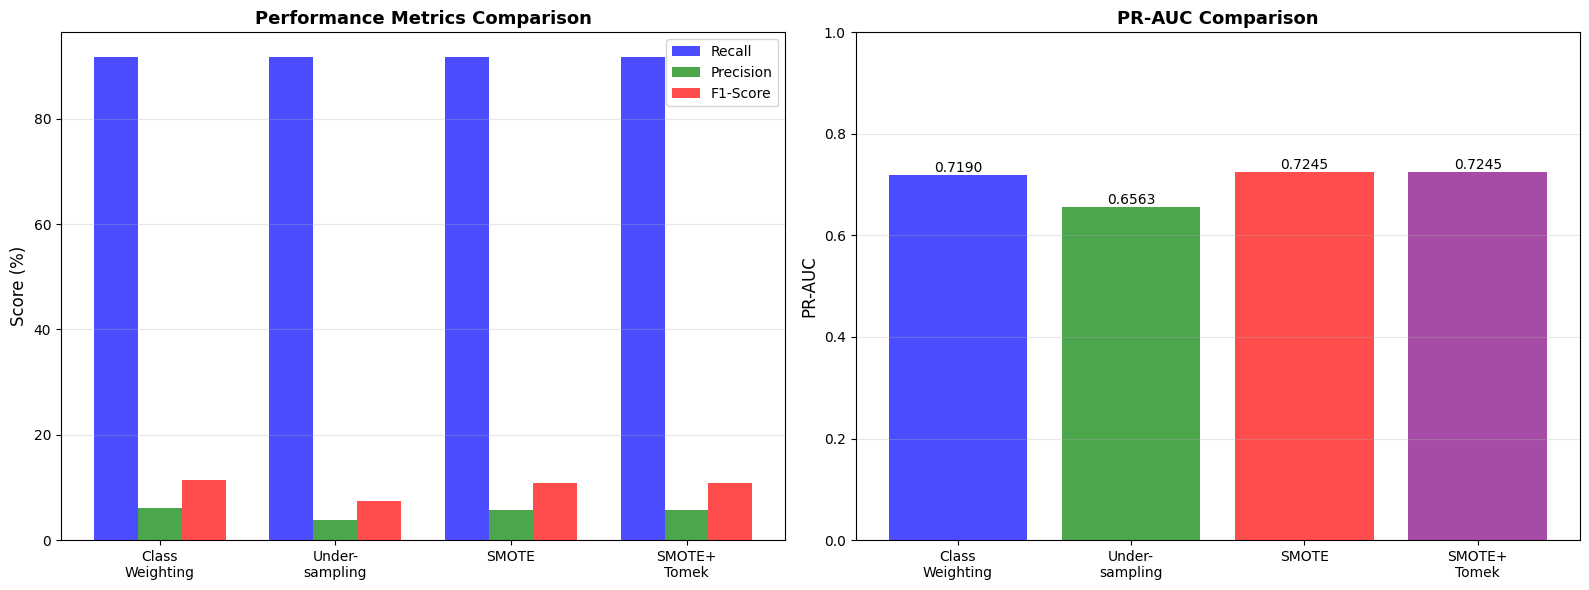

In [7]:
print("\n\n[STEP 3.3] Comparing All Techniques...")

# Create comparison table
comparison_data = {
    'Technique': ['Class Weighting', 'Random Undersampling', 'SMOTE', 'SMOTE + Tomek'],
    'Accuracy': [
        f"{metrics_balanced['accuracy']*100:.2f}%",
        f"{metrics_rus['accuracy']*100:.2f}%",
        f"{metrics_smote['accuracy']*100:.2f}%",
        f"{metrics_st['accuracy']*100:.2f}%"
    ],
    'Precision': [
        f"{metrics_balanced['precision']*100:.2f}%",
        f"{metrics_rus['precision']*100:.2f}%",
        f"{metrics_smote['precision']*100:.2f}%",
        f"{metrics_st['precision']*100:.2f}%"
    ],
    'Recall': [
        f"{metrics_balanced['recall']*100:.2f}%",
        f"{metrics_rus['recall']*100:.2f}%",
        f"{metrics_smote['recall']*100:.2f}%",
        f"{metrics_st['recall']*100:.2f}%"
    ],
    'F1-Score': [
        f"{metrics_balanced['f1']*100:.2f}%",
        f"{metrics_rus['f1']*100:.2f}%",
        f"{metrics_smote['f1']*100:.2f}%",
        f"{metrics_st['f1']*100:.2f}%"
    ],
    'PR-AUC': [
        f"{metrics_balanced['pr_auc']:.4f}",
        f"{metrics_rus['pr_auc']:.4f}",
        f"{metrics_smote['pr_auc']:.4f}",
        f"{metrics_st['pr_auc']:.4f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*70)
print("IMBALANCE HANDLING COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))


# Plot PR curves for all techniques
print("\nPlotting comparison curves...")
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

techniques = [
    ('Class Weighting', y_proba_balanced, 'blue'),
    ('Undersampling', y_proba_rus, 'green'),
    ('SMOTE', y_proba_smote, 'red'),
    ('SMOTE+Tomek', y_proba_st, 'purple')
]

pr_aucs = [
    metrics_balanced['pr_auc'],
    metrics_rus['pr_auc'],
    metrics_smote['pr_auc'],
    metrics_st['pr_auc']
]

for (name, proba, color), pr_auc in zip(techniques, pr_aucs):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ax.plot(recall, precision, label=f'{name} (PR-AUC = {pr_auc:.4f})',
            linewidth=2, color=color)

baseline = y_test.sum() / len(y_test)
ax.axhline(y=baseline, color='k', linestyle='--',
           label=f'Baseline = {baseline:.4f}', linewidth=1)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - Imbalance Handling Techniques',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.close()

# Plot metrics comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

techniques_names = ['Class\nWeighting', 'Under-\nsampling', 'SMOTE', 'SMOTE+\nTomek']
recalls = [metrics_balanced['recall']*100, metrics_rus['recall']*100,
           metrics_smote['recall']*100, metrics_st['recall']*100]
precisions = [metrics_balanced['precision']*100, metrics_rus['precision']*100,
              metrics_smote['precision']*100, metrics_st['precision']*100]
f1s = [metrics_balanced['f1']*100, metrics_rus['f1']*100,
       metrics_smote['f1']*100, metrics_st['f1']*100]

x = np.arange(len(techniques_names))
width = 0.25

axes[0].bar(x - width, recalls, width, label='Recall', color='blue', alpha=0.7)
axes[0].bar(x, precisions, width, label='Precision', color='green', alpha=0.7)
axes[0].bar(x + width, f1s, width, label='F1-Score', color='red', alpha=0.7)

axes[0].set_ylabel('Score (%)', fontsize=12)
axes[0].set_title('Performance Metrics Comparison', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(techniques_names)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# PR-AUC comparison
pr_auc_values = [metrics_balanced['pr_auc'], metrics_rus['pr_auc'],
                 metrics_smote['pr_auc'], metrics_st['pr_auc']]

colors = ['blue', 'green', 'red', 'purple']
bars = axes[1].bar(techniques_names, pr_auc_values, color=colors, alpha=0.7)

axes[1].set_ylabel('PR-AUC', fontsize=12)
axes[1].set_title('PR-AUC Comparison', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1])

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()
plt.close()

## Best Modeling Strategy

Now we will determine which strategy we will use to train our model.

In [12]:
# Find best by PR-AUC
best_idx = np.argmax([metrics_balanced['pr_auc'], metrics_rus['pr_auc'],
                       metrics_smote['pr_auc'], metrics_st['pr_auc']])
best_technique = ['Class Weighting', 'Undersampling', 'SMOTE', 'SMOTE+Tomek'][best_idx]

insights = f"""
PHASE 3 KEY FINDINGS
═══════════════════════════════════════════════════════════════════════

BEST TECHNIQUE: {best_technique}
────────────────────────────────────────────────────────────────

Performance:
• PR-AUC:    {best_metrics['pr_auc']:.4f} (highest among all techniques)
• Recall:    {best_metrics['recall']*100:.2f}% (fraud detection rate)
• Precision: {best_metrics['precision']*100:.2f}% (prediction accuracy)
• F1-Score:  {best_metrics['f1']*100:.2f}% (harmonic mean)

COMPARISON SUMMARY:
────────────────────────────────────────────────────────────────
1. Class Weighting: PR-AUC = {metrics_balanced['pr_auc']:.4f}
   - Easy to implement
   - No data modification
   - Good balance

2. Undersampling: PR-AUC = {metrics_rus['pr_auc']:.4f}
   - Loses information (discards majority samples)
   - Fast training
   - May underfit

3. SMOTE: PR-AUC = {metrics_smote['pr_auc']:.4f}
   - Creates synthetic samples
   - Preserves all original data
   - Risk of overfitting

4. SMOTE + Tomek: PR-AUC = {metrics_st['pr_auc']:.4f}
   - Combines over & undersampling
   - Cleans decision boundaries
   - More complex

NEXT STEPS:
────────────────────────────────────────────────────────────────
  Use {best_technique} for Advanced Models
  Apply to XGBoost/LightGBM training
  Optimize thresholds 
  Implement cost-sensitive evaluation 

═══════════════════════════════════════════════════════════════════════
"""

print(insights)


PHASE 3 KEY FINDINGS
═══════════════════════════════════════════════════════════════════════

BEST TECHNIQUE: SMOTE
────────────────────────────────────────────────────────────────

Performance:
• PR-AUC:    0.7245 (highest among all techniques)
• Recall:    91.84% (fraud detection rate)
• Precision: 5.78% (prediction accuracy)
• F1-Score:  10.88% (harmonic mean)

COMPARISON SUMMARY:
────────────────────────────────────────────────────────────────
1. Class Weighting: PR-AUC = 0.7190
   - Easy to implement
   - No data modification
   - Good balance

2. Undersampling: PR-AUC = 0.6563
   - Loses information (discards majority samples)
   - Fast training
   - May underfit

3. SMOTE: PR-AUC = 0.7245
   - Creates synthetic samples
   - Preserves all original data
   - Risk of overfitting

4. SMOTE + Tomek: PR-AUC = 0.7245
   - Combines over & undersampling
   - Cleans decision boundaries
   - More complex

NEXT STEPS:
────────────────────────────────────────────────────────────────
  Use S